In [2]:
import csv
import numpy as np
from typing import Set,Tuple, List
import torch
import torch.utils
import torch.utils.data
import torch.nn as nn
import torchvision
NoneType = type(None)
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from PIL import Image
import torchvision.transforms.functional as TF
from torchvision.models import vgg11
from torchvision.models import mobilenet_v2
import torchvision.transforms as transforms
import time


<h1 id="exercise-1"><strong>Exercise 1</strong></h1>


<font size="4px"><p>This method returns the fruit name by getting the string at a specific index of the set.</p>
<dl>
<dt>param fruit_id</dt>
<dd><p>The id of the fruit to get</p>
</dd>
<dt>param fruits</dt>
<dd><p>The set of fruits to choose the id from</p>
</dd>
<dt>return</dt>
<dd><p>The string corrosponding to the index <code>fruit_id</code></p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   It does not print the fruit at the correct index, why is the returned result wrong?</code><br />
<code>2   How could this be fixed?</code></div>
<p>This example demonstrates the issue: name1, name3 and name4 are expected to correspond to the strings at the indices 1, 3, and 4: 'orange', 'kiwi' and 'strawberry'..</p>
</font>

In [3]:
# You can copy this code to your personal pipeline project or execute it here.
def id_to_fruit(fruit_id: int, fruits: Set[str]) -> str:
    """
    This method returns the fruit name by getting the string at a specific index of the set.

    :param fruit_id: The id of the fruit to get
    :param fruits: The set of fruits to choose the id from
    :return: The string corrosponding to the index ``fruit_id``

    **This method is part of a series of debugging exercises.**
    **Each Python method of this series contains bug that needs to be found.**

    | ``1   It does not print the fruit at the correct index, why is the returned result wrong?``
    | ``2   How could this be fixed?``

    This example demonstrates the issue:
    name1, name3 and name4 are expected to correspond to the strings at the indices 1, 3, and 4:
    'orange', 'kiwi' and 'strawberry'..

    >>> name1 = id_to_fruit(1, {"apple", "orange", "melon", "kiwi", "strawberry"})
    >>> name3 = id_to_fruit(3, {"apple", "orange", "melon", "kiwi", "strawberry"})
    >>> name4 = id_to_fruit(4, {"apple", "orange", "melon", "kiwi", "strawberry"})
    """
    idx = 0
    for fruit in fruits:
        if fruit_id == idx:
            return fruit
        idx += 1
    raise RuntimeError(f"Fruit with id {fruit_id} does not exist")



In [4]:
name1 = id_to_fruit(1, {"apple", "orange", "melon", "kiwi", "strawberry"})
name3 = id_to_fruit(3, {"apple", "orange", "melon", "kiwi", "strawberry"})
name4 = id_to_fruit(4, {"apple", "orange", "melon", "kiwi", "strawberry"})


## Solution Exercise 1


### Problem Description

#### The function is supposed to return a fruit name using its index. However, the returned fruit is incorrect or inconsistent and doesn't always match with the expected index.

### Buggy Code and Demonstration

In [5]:
print("name1 =", name1) #expected to be "orange"
print("name3 =", name3) #expected to be "kiwi"
print("name4 =", name4) #expected to be "strawberry"

name1 = melon
name3 = kiwi
name4 = strawberry


### Explanation

#### The Bug happens because the function "set" doesn't preserve element order in Python.
#### Because the order changes, the indices are inconsistent.

### Fixed Solution

In [6]:
def id_to_fruit_fixed(fruit_id: int, fruits: List[str]) -> str:
    return fruits[fruit_id]


fruits = ["apple", "orange", "melon", "kiwi", "strawberry"]

name1 = id_to_fruit_fixed(1, fruits) # Expected "orange"
name3 = id_to_fruit_fixed(3, fruits) # Expected "kiwi"
name4 = id_to_fruit_fixed(4, fruits) # Expected "strawberry"

print("name1 =", name1)
print("name3 =", name3)
print("name4 =", name4)

name1 = orange
name3 = kiwi
name4 = strawberry


#### The issue was fixed by replacing 'set' with a 'list'.
#### Lists preserve element order in Python, in this case, the order of the fruit list. Therefore the indices become stable and predictable.

<h1 id="exercise-2"><strong>Exercise 2</strong></h1>


<font size="4px"><p>This method will flip the x and y coordinates in the coords array.</p>
<dl>
<dt>param coords</dt>
<dd><p>A numpy array of bounding box coordinates with shape [n,5] in format: :</p>
<pre><code>[[x11, y11, x12, y12, classid1],
 [x21, y21, x22, y22, classid2],
 ...
 [xn1, yn1, xn2, yn2, classid3]]</code></pre>
</dd>
<dt>return</dt>
<dd><p>The new numpy array where the x and y coordinates are flipped.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   Can you spot the obvious error?</code><br />
<code>2   After fixing the obvious error it is still wrong, how can this be fixed?</code></div>
</font>

<font size="4px"><p>The example demonstrates the issue. The returned swapped_coords are expected to have swapped x and y coordinates in each of the rows.</p>
</font>

In [7]:
# You can copy this code to your personal pipeline project or execute it here.
def swap(coords: np.ndarray):
    """
    This method will flip the x and y coordinates in the coords array.

    :param coords: A numpy array of bounding box coordinates with shape [n,5] in format:
        ::

            [[x11, y11, x12, y12, classid1],
             [x21, y21, x22, y22, classid2],
             ...
             [xn1, yn1, xn2, yn2, classid3]]

    :return: The new numpy array where the x and y coordinates are flipped.

    **This method is part of a series of debugging exercises.**
    **Each Python method of this series contains bug that needs to be found.**

    | ``1   Can you spot the obvious error?``
    | ``2   After fixing the obvious error it is still wrong, how can this be fixed?``

    >>> import numpy as np
    >>> coords = np.array([[10, 5, 15, 6, 0],
    ...                    [11, 3, 13, 6, 0],
    ...                    [5, 3, 13, 6, 1],
    ...                    [4, 4, 13, 6, 1],
    ...                    [6, 5, 13, 16, 1]])
    >>> swapped_coords = swap(coords)

    The example demonstrates the issue. The returned swapped_coords are expected to have swapped
    x and y coordinates in each of the rows.
    """
    coords[:, 0], coords[:, 1], coords[:, 2], coords[:, 3], = coords[:, 1], coords[:, 1], coords[:, 3], coords[:, 2]
    return coords



In [8]:
import numpy as np
coords = np.array([[10, 5, 15, 6, 0],
                   [11, 3, 13, 6, 0],
                   [5, 3, 13, 6, 1],
                   [4, 4, 13, 6, 1],
                   [6, 5, 13, 16, 1]])
swapped_coords = swap(coords)


### Solution Exercise 2

#### Problem Description

#### The function is supposed to swap the x and y coordinates of each bounding box. However, the returned coordinates are incorrect because the swapping operation is not implemented properly.

#### Buggy Code and Demonstration

In [9]:
print("Returned coordinates:")
print(swapped_coords)

# Expected output:
# [[ 5,10, 6,15,0],
# [ 3,11, 6,13,0],
# [ 3, 5, 6,13,1],
# [ 4, 4, 6,13,1],
# [ 5, 6,16,13,1]]


Returned coordinates:
[[ 5  5  6  6  0]
 [ 3  3  6  6  0]
 [ 3  3  6  6  1]
 [ 4  4  6  6  1]
 [ 5  5 16 16  1]]


### Explanation

#### The returned coordinates are incorrect because the code uses coords[:,1] twice instead of properly swapping the x and y coordinates.
#### As a result, some original x values are overwritten and lost.

#### Incorrect:
coords[:,1], coords[:,1], coords[:,3], coords[:,2]

#### Correct:
coords[:,1], coords[:,0], coords[:,3], coords[:,2]

### Fixed Solution

In [10]:
# Fixed Solution (First Bug Only)

def swap(coords: np.ndarray):

    coords[:, 0], coords[:, 1], coords[:, 2], coords[:, 3] = coords[:, 1], coords[:, 0], coords[:, 3], coords[:, 2]

    return coords


coords = np.array([
    [10, 5, 15, 6, 0],
    [11, 3, 13, 6, 0],
    [5, 3, 13, 6, 1],
    [4, 4, 13, 6, 1],
    [6, 5, 13, 16, 1]
])

swapped_coords = swap(coords)

print(swapped_coords)

# Expected output:
# [[ 5,10, 6,15,0],
# [ 3,11, 6,13,0],
# [ 3, 5, 6,13,1],
# [ 4, 4, 6,13,1],
# [ 5, 6,16,13,1]]

[[ 5  5  6  6  0]
 [ 3  3  6  6  0]
 [ 3  3  6  6  1]
 [ 4  4  6  6  1]
 [ 5  5 16 16  1]]


#### We can see that in theory the bug is fixed, but te resoults are the same, there is another bug that is that Numpy is overwritting the values when it is doing the swap. As a result, some original coordinate values ​​are lost before the swap is completed.

#### The solution is to use .copy() so NumPy creates temporary copies of the original values ​​before replacing them.

In [11]:
def swap(coords: np.ndarray):

    coords[:, 0], coords[:, 1], coords[:, 2], coords[:, 3] = coords[:, 1].copy(), coords[:, 0].copy(), coords[:, 3].copy(), coords[:, 2].copy()

    return coords


coords = np.array([
    [10, 5, 15, 6, 0],
    [11, 3, 13, 6, 0],
    [5, 3, 13, 6, 1],
    [4, 4, 13, 6, 1],
    [6, 5, 13, 16, 1]
])

swapped_coords = swap(coords)

print(swapped_coords)

# Expected output:
# [[ 5,10, 6,15,0],
# [ 3,11, 6,13,0],
# [ 3, 5, 6,13,1],
# [ 4, 4, 6,13,1],
# [ 5, 6,16,13,1]]

[[ 5 10  6 15  0]
 [ 3 11  6 13  0]
 [ 3  5  6 13  1]
 [ 4  4  6 13  1]
 [ 5  6 16 13  1]]


#### The bug was fully fixed by correcting the swap order and using .copy().
#### The first bug happened because the code used coords[:, 1] twice instead of properly swapping the X and Y coordinates.
#### The second bug happened because NumPy overwrites array values in memory during the assignment operation.
#### Using .copy() preserves the original values before the swap occurs, making the coordinate swap stable and correct.

<h1 id="exercise-3"><strong>Exercise 3</strong></h1>


<font size="4px"><p>This code plots the precision-recall curve based on data from a .csv file, where precision is on the x-axis and recall is on the y-axis. It it not so important right now what precision and recall means.</p>
<dl>
<dt>param csv_file_path</dt>
<dd><p>The CSV file containing the data to plot.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   For some reason the plot is not showing correctly, can you find out what is going wrong?</code><br />
<code>2   How could this be fixed?</code></div>
<p>This example demonstrates the issue. It first generates some data in a csv file format and the plots it using the <code>plot_data</code> method. If you manually check the coordinates and then check the plot, they do not correspond.</p>
</font>

In [12]:
# You can copy this code to your personal pipeline project or execute it here.
def plot_data(csv_file_path: str):
    """
    This code plots the precision-recall curve based on data from a .csv file,
    where precision is on the x-axis and recall is on the y-axis.
    It it not so important right now what precision and recall means.

    :param csv_file_path: The CSV file containing the data to plot.


    **This method is part of a series of debugging exercises.**
    **Each Python method of this series contains bug that needs to be found.**

    | ``1   For some reason the plot is not showing correctly, can you find out what is going wrong?``
    | ``2   How could this be fixed?``

    This example demonstrates the issue.
    It first generates some data in a csv file format and the plots it using the ``plot_data`` method.
    If you manually check the coordinates and then check the plot, they do not correspond.

    >>> f = open("data_file.csv", "w")
    >>> w = csv.writer(f)
    >>> _ = w.writerow(["precision", "recall"])
    >>> w.writerows([[0.013,0.951],
    ...              [0.376,0.851],
    ...              [0.441,0.839],
    ...              [0.570,0.758],
    ...              [0.635,0.674],
    ...              [0.721,0.604],
    ...              [0.837,0.531],
    ...              [0.860,0.453],
    ...              [0.962,0.348],
    ...              [0.982,0.273],
    ...              [1.0,0.0]])
    >>> f.close()
    >>> plot_data('data_file.csv')
    """
    # load data
    results = []
    with open(csv_file_path) as result_csv:
        csv_reader = csv.reader(result_csv, delimiter=',')
        next(csv_reader)
        for row in csv_reader:
            results.append(row)
        results = np.stack(results)

    # plot precision-recall curve
    plt.plot(results[:, 1], results[:, 0])
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.show()



In [13]:
f = open("data_file.csv", "w")
w = csv.writer(f)
_ = w.writerow(["precision", "recall"])
w.writerows([[0.013,0.951],
             [0.376,0.851],
             [0.441,0.839],
             [0.570,0.758],
             [0.635,0.674],
             [0.721,0.604],
             [0.837,0.531],
             [0.860,0.453],
             [0.962,0.348],
             [0.982,0.273],
             [1.0,0.0]])
f.close()
plot_data('data_file.csv')


ValueError: all input arrays must have the same shape

### Solution Exercise 3

#### First, the original code does not plot the graph correctly because it was written for an older NumPy version, to make it run we need to make some changes.

In [14]:
# You can copy this code to your personal pipeline project or execute it here.
def plot_data(csv_file_path: str):
    
    # load data
    results = []
    with open(csv_file_path) as result_csv:
        csv_reader = csv.reader(result_csv, delimiter=',')
        next(csv_reader)
        for row in csv_reader:
            results.append(row)
        results = np.array(results, dtype=float)                                    # Added dtype=float to convert string data to float for plotting

    # plot precision-recall curve
    plt.plot(results[:, 1], results[:, 0])
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.show()



#### First fix was de Numpy Compatibility
#### Original code  |  results = np.stack(results)
#### Changed to | results = np.array(results, dtype=float)

#### The original code used np.stack(results) to combine the CSV rows into a NumPy array. However, in the current NumPy version this produced a compatibility error.

#### The solution converts the list into a NumPy array and the CSV string values into float numbers.

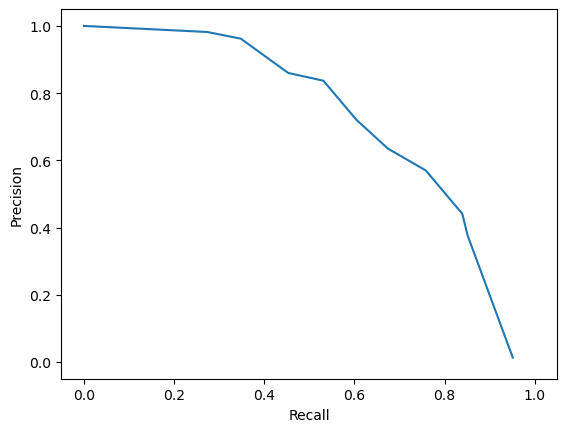

In [15]:
f = open("data_file.csv", "w", newline="")                                  # Added newline="" to prevent extra blank lines in the CSV file on Windows
w = csv.writer(f)
_ = w.writerow(["precision", "recall"])
w.writerows([[0.013,0.951],
             [0.376,0.851],
             [0.441,0.839],
             [0.570,0.758],
             [0.635,0.674],
             [0.721,0.604],
             [0.837,0.531],
             [0.860,0.453],
             [0.962,0.348],
             [0.982,0.273],
             [1.0,0.0]])
f.close()
plot_data('data_file.csv')


#### Second Fix was the CSV File writing
#### Original code | f = open("data_file.csv", "w")
#### Changed to | f = open("data_file.csv", "w", newline="")
#### With this new parameter 'newline=""' makes Python write CSV file correctly. Without it may have some reading issues.
#### After adding this, the CSV file is loaded and also written correctly before plotting the graph.

### Plot Bug

#### But now, we can se that the graph has some errors the information given said:
#### precision is on the x-axis
#### recall is on the y-axis
#### However the code plots: plt.plot(results[:, 1], results[:, 0])
#### This means that the axes are swapped, recall is plotted on the x-axis and precision is plotted on the y-axis but also the labels are reversed:
#### plt.xlabel('Recall')
#### plt.ylabel('Precision')
#### As a result, the graph dosen't correspond to the expected output.

In [16]:
def plot_data(csv_file_path: str):
    
    # load data
    results = []
    with open(csv_file_path) as result_csv:
        csv_reader = csv.reader(result_csv, delimiter=',')
        next(csv_reader)
        for row in csv_reader:
            results.append(row)
        results = np.array(results, dtype=float)

    # plot precision-recall curve
    plt.plot(results[:, 0], results[:, 1])                      # Swapped indices to plot precision on x-axis and recall on y-axis
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.xlabel('Precision')                                     # Swapped labels to match the swapped axes
    plt.ylabel('Recall')
    plt.show()


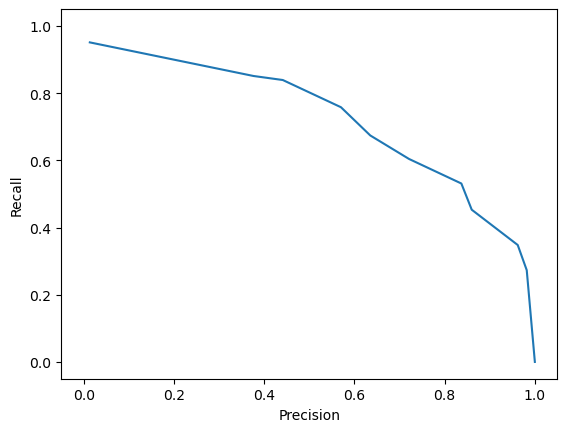

In [17]:
f = open("data_file.csv", "w", newline="")
w = csv.writer(f)
_ = w.writerow(["precision", "recall"])
w.writerows([[0.013,0.951],
             [0.376,0.851],
             [0.441,0.839],
             [0.570,0.758],
             [0.635,0.674],
             [0.721,0.604],
             [0.837,0.531],
             [0.860,0.453],
             [0.962,0.348],
             [0.982,0.273],
             [1.0,0.0]])
f.close()
plot_data('data_file.csv')


#### After fixing the compatibility issues and correcting the swapped axes, the graph now correctly represents the precision-recall curve described in the problem statement.

<h1 id="generator-for-exercise-4">** Generator (for Exercise 4)**</h1>


<font size="4px"><p>Generator class for the GAN</p>
</font>

In [18]:
# You can copy this code to your personal pipeline project or execute it here.
class Generator(nn.Module):
    """
    Generator class for the GAN
    """

    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        output = output.view(x.size(0), 1, 28, 28)
        return output



<h1 id="discriminator-for-exercise-4">** Discriminator (for Exercise 4)**</h1>


<font size="4px"><p>Discriminator class for the GAN</p>
</font>

In [19]:
# You can copy this code to your personal pipeline project or execute it here.
class Discriminator(nn.Module):
    """
    Discriminator class for the GAN
    """
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        output = self.model(x)
        return output



<h1 id="exercise-4">** Exercise 4**</h1>


<font size="4px"><p>The method trains a Generative Adversarial Network and is based on: <a href="https://realpython.com/generative-adversarial-networks/">https://realpython.com/generative-adversarial-networks/</a></p>
<p>The Generator network tries to generate convincing images of handwritten digits. The Discriminator needs to detect if the image was created by the Generater or if the image is a real image from a known dataset (MNIST). If both the Generator and the Discriminator are optimized, the Generator is able to create images that are difficult to distinguish from real images. This is goal of a GAN.</p>
<p>This code produces the expected results at first attempt at about 50 epochs.</p>
<dl>
<dt>param batch_size</dt>
<dd><p>The number of images to train in one epoch.</p>
</dd>
<dt>param num_epochs</dt>
<dd><p>The number of epochs to train the gan.</p>
</dd>
<dt>param device</dt>
<dd><p>The computing device to use. If CUDA is installed and working then <span class="title-ref">cuda:0</span> is chosen otherwise 'cpu' is chosen. Note: Training a GAN on the CPU is very slow.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<p>It contains at least two bugs: one structural bug and one cosmetic bug. Both bugs are from the original tutorial.</p>
<div class="line-block"><code>1   Changing the batch_size from 32 to 64 triggers the structural bug.</code><br />
<code>2   Can you also spot the cosmetic bug?</code><br />
<code>Note: to fix this bug a thorough understanding of GANs is not necessary.</code></div>
<p>Change the batch size to 64 to trigger the bug with message: ValueError: "Using a target size (torch.Size([128, 1])) that is different to the input size (torch.Size([96, 1])) is deprecated. Please ensure they have the same size."</p>
</font>

In [20]:
# You can copy this code to your personal pipeline project or execute it here.
def train_gan(batch_size: int = 32, num_epochs: int = 100, device: str = "cuda:0" if torch.cuda.is_available() else "cpu"):
    """
    The method trains a Generative Adversarial Network and is based on:
    https://realpython.com/generative-adversarial-networks/

    The Generator network tries to generate convincing images of handwritten digits.
    The Discriminator needs to detect if the image was created by the Generater or if the image is a real image from
    a known dataset (MNIST).
    If both the Generator and the Discriminator are optimized, the Generator is able to create images that are difficult
    to distinguish from real images. This is goal of a GAN.

    This code produces the expected results at first attempt at about 50 epochs.

    :param batch_size: The number of images to train in one epoch.
    :param num_epochs: The number of epochs to train the gan.
    :param device: The computing device to use. If CUDA is installed and working then `cuda:0` is chosen
        otherwise 'cpu' is chosen. Note: Training a GAN on the CPU is very slow.

    **This method is part of a series of debugging exercises.**
    **Each Python method of this series contains bug that needs to be found.**

    It contains at least two bugs: one structural bug and one cosmetic bug. Both bugs are from the original tutorial.

    | ``1   Changing the batch_size from 32 to 64 triggers the structural bug.``
    | ``2   Can you also spot the cosmetic bug?``
    | ``Note: to fix this bug a thorough understanding of GANs is not necessary.``

    Change the batch size to 64 to trigger the bug with message:
    ValueError: "Using a target size (torch.Size([128, 1])) that is different to the input size (torch.Size([96, 1])) is deprecated. Please ensure they have the same size."

    >>> train_gan(batch_size=32, num_epochs=100)
    """
    # Add/adjust code.

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

    try:
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)
    except:
        print("Failed to download MNIST, retrying with different URL")
        # see: https://github.com/pytorch/vision/blob/master/torchvision/datasets/mnist.py
        torchvision.datasets.MNIST.resources = [
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
             'f68b3c2dcbeaaa9fbdd348bbdeb94873'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
             'd53e105ee54ea40749a09fcbcd1e9432'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
             '9fb629c4189551a2d022fa330f9573f3'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz',
             'ec29112dd5afa0611ce80d1b7f02629c')
        ]
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)

    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)

    # example data
    real_samples, mnist_labels = next(iter(train_loader))

    fig = plt.figure()
    for i in range(16):
        sub = fig.add_subplot(4, 4, 1 + i)
        sub.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
        sub.axis('off')

    fig.tight_layout()
    fig.suptitle("Real images")
    display(fig)

    time.sleep(5)

    # Set up training
    discriminator = Discriminator().to(device)
    generator = Generator().to(device)
    lr = 0.0001
    loss_function = nn.BCELoss()
    optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
    optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

    # train
    for epoch in range(num_epochs):
        for n, (real_samples, mnist_labels) in enumerate(train_loader):

            # Data for training the discriminator
            real_samples = real_samples.to(device=device)
            real_samples_labels = torch.ones((batch_size, 1)).to(device=device)
            latent_space_samples = torch.randn((batch_size, 100)).to(device=device)
            generated_samples = generator(latent_space_samples)
            generated_samples_labels = torch.zeros((batch_size, 1)).to(device=device)
            all_samples = torch.cat((real_samples, generated_samples))
            all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

            # Training the discriminator
            discriminator.zero_grad()
            output_discriminator = discriminator(all_samples)
            loss_discriminator = loss_function(output_discriminator, all_samples_labels)
            loss_discriminator.backward()
            optimizer_discriminator.step()

            # Data for training the generator
            latent_space_samples = torch.randn((batch_size, 100)).to(device=device)

            # Training the generator
            generator.zero_grad()
            generated_samples = generator(latent_space_samples)
            output_discriminator_generated = discriminator(generated_samples)
            loss_generator = loss_function(output_discriminator_generated, real_samples_labels)
            loss_generator.backward()
            optimizer_generator.step()

            # Show loss and samples generated
            if n == batch_size - 1:
                name = f"Generate images\n Epoch: {epoch} Loss D.: {loss_discriminator:.2f} Loss G.: {loss_generator:.2f}"
                generated_samples = generated_samples.detach().cpu().numpy()
                fig = plt.figure()
                for i in range(16):
                    sub = fig.add_subplot(4, 4, 1 + i)
                    sub.imshow(generated_samples[i].reshape(28, 28), cmap="gray_r")
                    sub.axis('off')
                fig.suptitle(name)
                fig.tight_layout()
                clear_output(wait=False)
                display(fig)



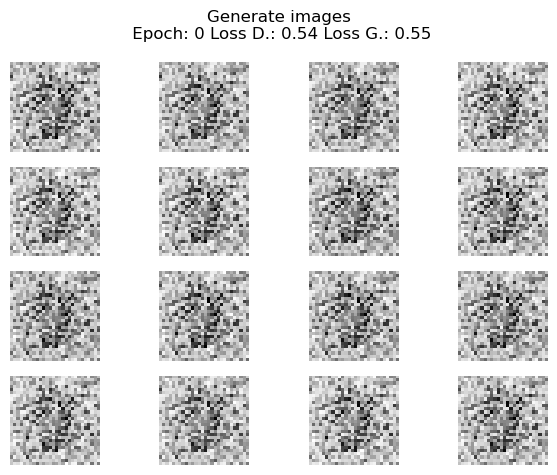

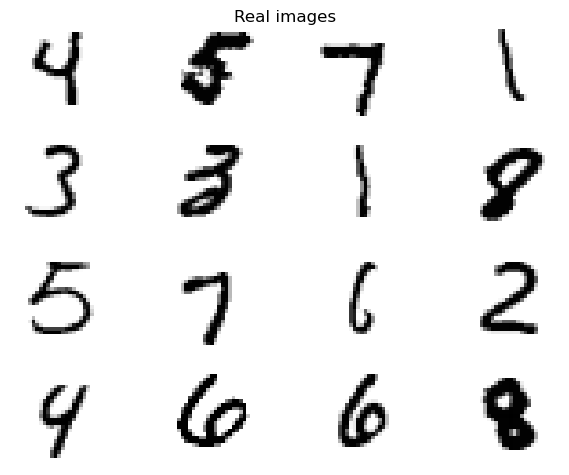

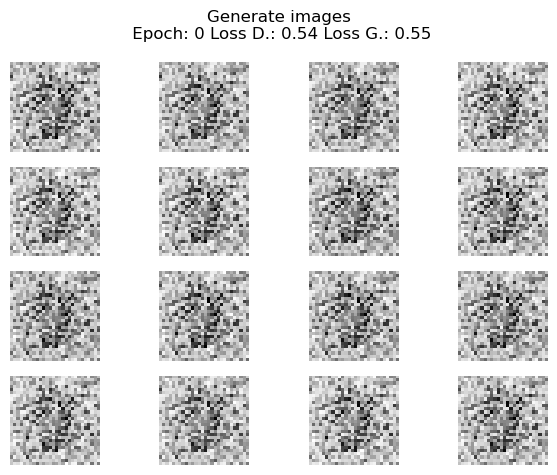

In [28]:
train_gan(batch_size=32, num_epochs=1) # Original code with num_epochs=100


## Solution Exercise 4

## 1. Undestanding the problem

#### A GAN (Generative Adversarial Network) is a deep learning model composed of two neural networks:

#### - Generator
#### - Discriminator

#### Both networks compete against each other during training.

### What ia a "GAN"?

#### The Generator creates fake handwritten digit images from random noise.

#### The Discriminator analyzes images and predicts whether they are: real or generated (fake)

### Generator vs Discriminator
####  The Generator tries to fool the Discriminator.

#### The Discriminator tries to correctly detect fake images.

#### During training, both networks improve together.

### Generator (for Exercise 4)

In [24]:
# You can copy this code to your personal pipeline project or execute it here.
class Generator(nn.Module):
    """
    Generator class for the GAN
    """

    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(                   # Sequential nerual network / Input 100 randim values, Output 784 values (28*28)
            nn.Linear(100, 256),                      # Fully connected layer 100 to 256 neurons
            nn.ReLU(),
            nn.Linear(256, 512),                      # Hidden layer
            nn.ReLU(),
            nn.Linear(512, 1024),                     # Hidden layer
            nn.ReLU(),
            nn.Linear(1024, 784),                     # Final layer outputs 784 values
            nn.Tanh(),                                # Tanh normalizes outputs between -1 and 1
        )

    def forward(self, x):
        output = self.model(x)                        # Pass data through the neural network
        output = output.view(x.size(0), 1, 28, 28)    # Reshape 784 values into a 28x28 image
        return output



### Discriminator (for Exercise 4)

In [25]:
# You can copy this code to your personal pipeline project or execute it here.
class Discriminator(nn.Module):
    """
    Discriminator class for the GAN
    """
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(             # Sequential neural network / Input: 784 values (28x28 image flattened) / Output: probability between 0 and 1
            nn.Linear(784, 1024),               # First fully connected layer
            nn.ReLU(),
            nn.Dropout(0.3),                    # Dropout randomly disables 30% of neurons to help prevent overfitting
            nn.Linear(1024, 512),               # Hidden layer
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),                # Hidden layer
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),                  # Final layer outputs a single value representing the probability that the input image is real / Returns a single value
            nn.Sigmoid(),                       # Sigmoid normalizes output to be between 0 and 1, representing a probability
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)              # Flatten 28x28 image into 784 values
        output = self.model(x)                  # Pass image through the neural network
        return output



### 1.1 Exercise objective
### The exercise asks to identify and fix a structural bug in the GAN implementation.

#### The bug appears when changing:
#### - batch_size from 32 to 64

#### The expected error is a ValueError caused by tensor size mismatch.

### 1.2 Structural bug
#### ValueError: "Using a target size (torch.Size([128, 1])) that is different to the input size (torch.Size([96, 1])) is deprecated. Please ensure they have the same size."

#### This happens because some tensors do not have matching dimensions. The mismatch happens because the last batch may contain fewer samples than the selected batch_size.

## 2. Running the original code

In [26]:
# You can copy this code to your personal pipeline project or execute it here.
def train_gan(batch_size: int = 32, num_epochs: int = 100, device: str = "cuda:0" if torch.cuda.is_available() else "cpu"):
    
    # Add/adjust code.

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])                   # Normalize MNIST images between -1 and 1

    try:                                                                                                            # Try downloading MNIST dataset
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)
    except:                                                                                                         # If download fails, retry using backup URLs
        print("Failed to download MNIST, retrying with different URL")
        # see: https://github.com/pytorch/vision/blob/master/torchvision/datasets/mnist.py
        torchvision.datasets.MNIST.resources = [
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
             'f68b3c2dcbeaaa9fbdd348bbdeb94873'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
             'd53e105ee54ea40749a09fcbcd1e9432'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
             '9fb629c4189551a2d022fa330f9573f3'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz',
             'ec29112dd5afa0611ce80d1b7f02629c')
        ]
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)            # Retry dataset download

    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)                      # Create batches of data

    # example data
    real_samples, mnist_labels = next(iter(train_loader))                                                           # Display example real images

    fig = plt.figure()
    for i in range(16):
        sub = fig.add_subplot(4, 4, 1 + i)
        sub.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
        sub.axis('off')

    fig.tight_layout()
    fig.suptitle("Real images")
    display(fig)

    time.sleep(5)

    # Set up training
    discriminator = Discriminator().to(device)                                                                      # Initialize GAN networks
    generator = Generator().to(device)
    lr = 0.0001                                                                                                     # Learning rate
    loss_function = nn.BCELoss()                                                                                    # Binary Cross Entropy loss
    optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)                                   # Optimizers
    optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

    # train
    for epoch in range(num_epochs):                                                                                 # Training loop
        for n, (real_samples, mnist_labels) in enumerate(train_loader):

            # Data for training the discriminator
            real_samples = real_samples.to(device=device)                                                           # Move real images to device
            real_samples_labels = torch.ones((batch_size, 1)).to(device=device)                                     # Labels for real images
            latent_space_samples = torch.randn((batch_size, 100)).to(device=device)                                 # Generate random latent vectors
            generated_samples = generator(latent_space_samples)                                                     # Generate fake images
            generated_samples_labels = torch.zeros((batch_size, 1)).to(device=device)                               # Generate fake images
            all_samples = torch.cat((real_samples, generated_samples))                                              # Combine real and fake samples
            all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))                         # Combine labels

            # Training the discriminator
            discriminator.zero_grad()
            output_discriminator = discriminator(all_samples)
            loss_discriminator = loss_function(output_discriminator, all_samples_labels)
            loss_discriminator.backward()
            optimizer_discriminator.step()

            # Data for training the generator
            latent_space_samples = torch.randn((batch_size, 100)).to(device=device)

            # Training the generator
            generator.zero_grad()
            generated_samples = generator(latent_space_samples)
            output_discriminator_generated = discriminator(generated_samples)
            loss_generator = loss_function(output_discriminator_generated, real_samples_labels)                     # Generator tries to fool discriminator
            loss_generator.backward()
            optimizer_generator.step()

            # Show loss and samples generated
            if n == batch_size - 1:                                                                                 # Show generated images during training
                name = f"Generate images\n Epoch: {epoch} Loss D.: {loss_discriminator:.2f} Loss G.: {loss_generator:.2f}"
                generated_samples = generated_samples.detach().cpu().numpy()
                fig = plt.figure()
                for i in range(16):
                    sub = fig.add_subplot(4, 4, 1 + i)
                    sub.imshow(generated_samples[i].reshape(28, 28), cmap="gray_r")
                    sub.axis('off')
                fig.suptitle(name)
                fig.tight_layout()
                clear_output(wait=False)
                display(fig)



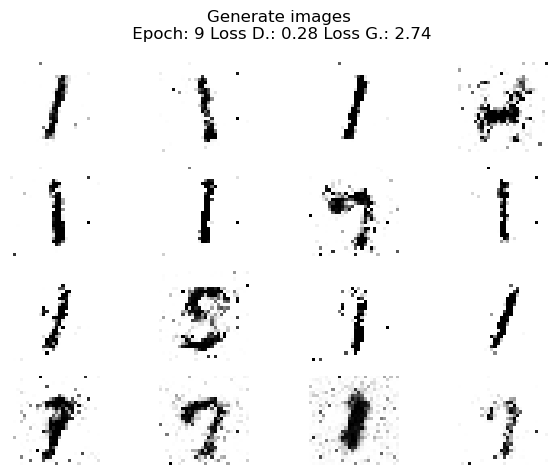

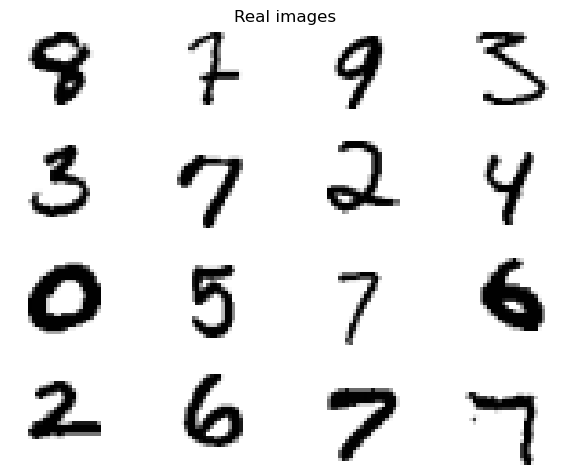

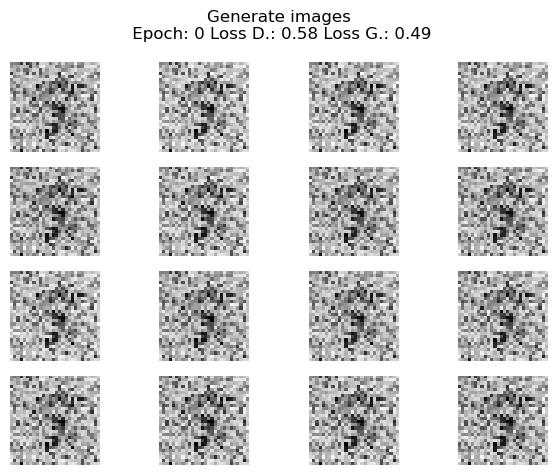

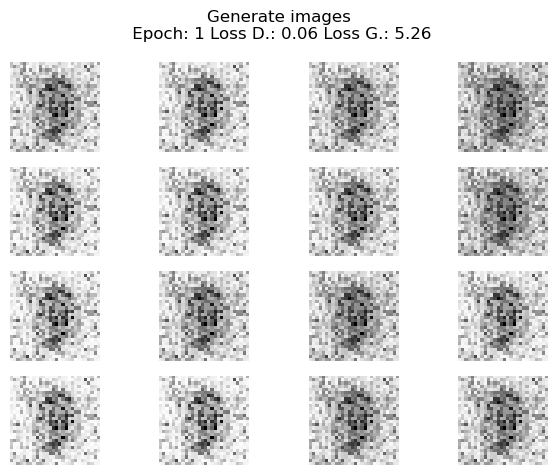

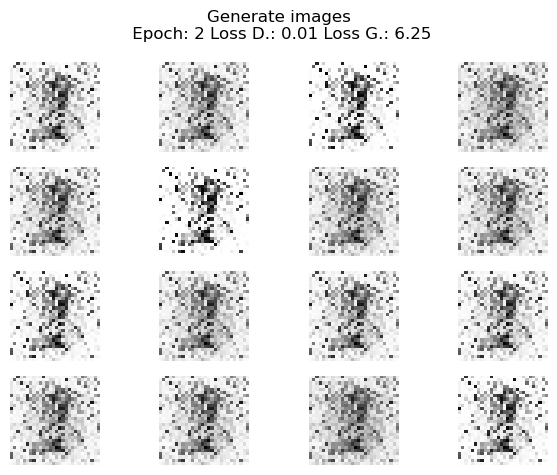

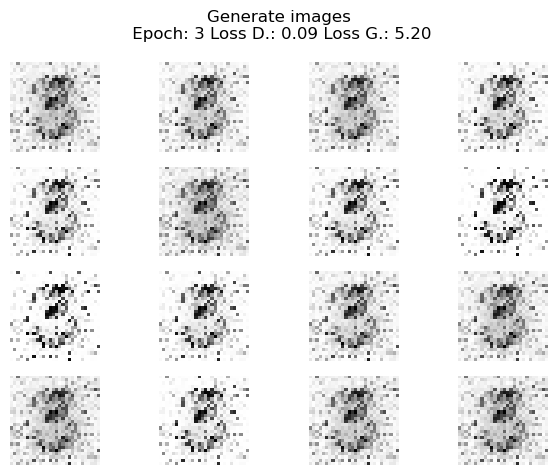

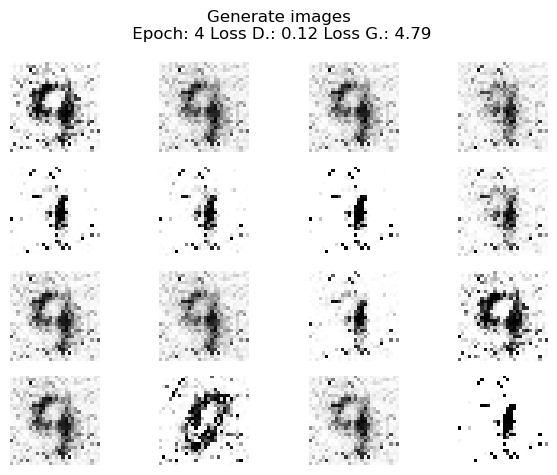

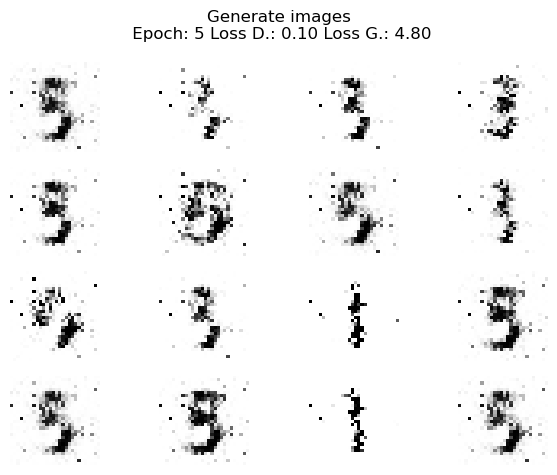

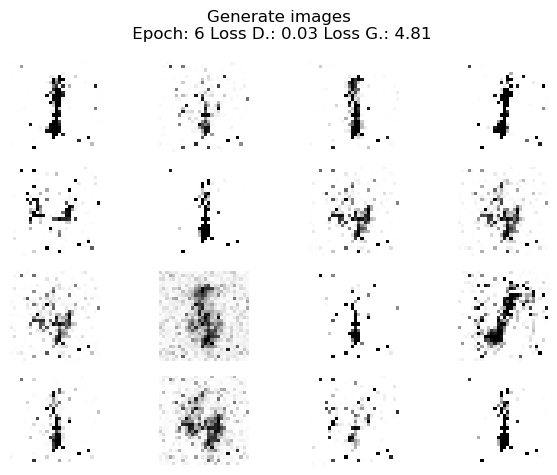

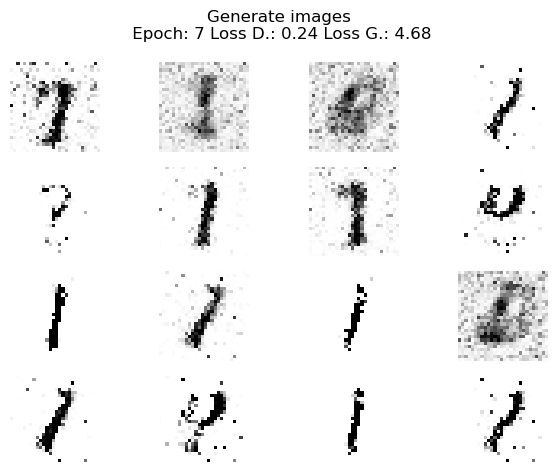

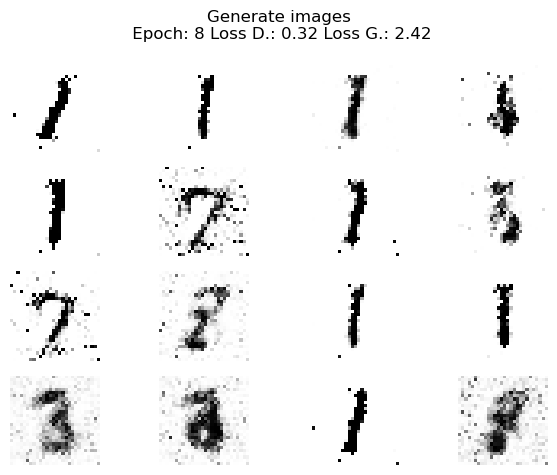

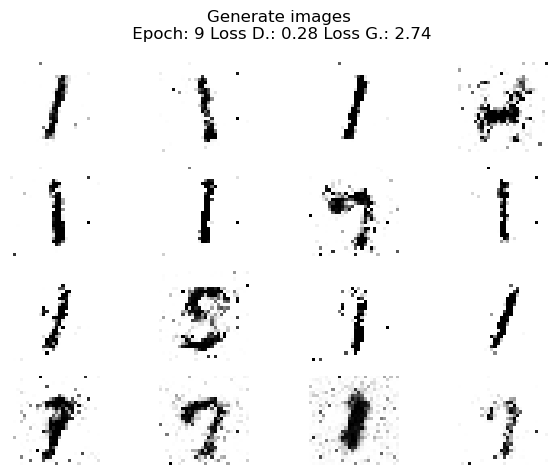

In [27]:
train_gan(batch_size=32, num_epochs=10)                                                                             # Run original implementation with only 10 epochs for testing

#### The original implementation works correctly with:

#### - batch_size = 32

#### For this analysis, only 10 epochs were executed instead of 100 because the goal is not to fully train the GAN, but to verify that the original implementation works before reproducing the bug.

#### Even with only 10 epochs, the training process can already be observed:

#### Early epochs generate mostly random noise, but later epochs begin producing recognizable handwritten digits, this means that the Generator progressively improves during training

#### This confirms that the Generator and Discriminator are working correctly, the training loop executes properly with the default configuration and the structural bug does not appear when batch_size=32

#### The next step is to reproduce the bug by changing the batch size from 32 to 64, as described in the exercise.




## 3. Reproducing the bug

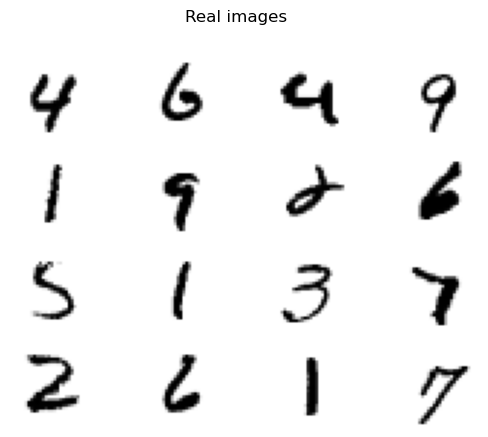

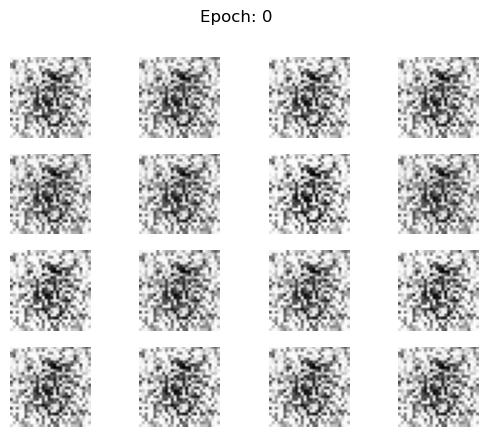

ValueError: Using a target size (torch.Size([128, 1])) that is different to the input size (torch.Size([96, 1])) is deprecated. Please ensure they have the same size.

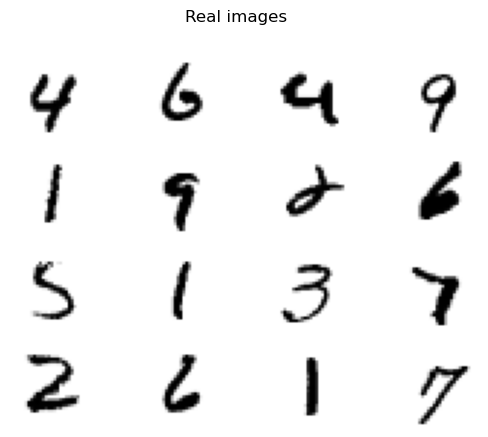

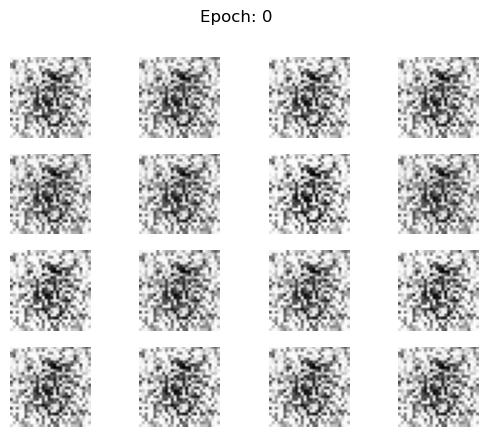

In [ ]:
train_gan(batch_size=64, num_epochs=10)

#### When changing 'batch_size' = 32 to 'batch_size=64'
#### the training process crashes and stop with a ValueError.

#### The error appears during discriminator training at: loss_discriminator = loss_function(output_discriminator, all_samples_labels)

#### PyTorch reports that the tensor dimensions do not match:

#### - target size: torch.Size([128, 1])
#### - input size: torch.Size([96, 1])

#### This indicates that the expected labels tensor has 128 samples, while the discriminator output only contains 96 samples.
#### Therefore, the generator and discriminator no longer work with tensors of compatible dimensions, which is why the error only appears when the batch size is increased to 64.


## 4. Analyzing the error
#### Why does the code fail with some batch sizes?
#### The code assumes that every batch always contains exactly the same number of samples:

In [ ]:
(batch_size, 1)

### However, this is not always true.

### The MNIST dataset contains: 60000 images

#### Some batch sizes divide the dataset perfectly:

#### 60000 / 32 = 1875

#### or:

#### 60000 / 96 = 625

#### In those cases, every batch contains the expected number of images.

#### But batch sizes such as:

#### 64

#### do not divide the dataset exactly:

#### 60000 / 64 = 937.5

#### This means the final batch contains fewer samples than expected.

#### The bug occurs because the code still creates labels using the fixed batch size:


In [ ]:
torch.ones((batch_size, 1))


#### instead of using the actual batch size of the current data.

#### As a result:

#### the labels tensor contains 128 elements, while the discriminator output only contains 96 elements which causes the tensor dimension mismatch error.

#### A properly implemented deep learning training loop should work with any batch size by dynamically adapting to the real batch dimensions.

## 5. Possible solutions

## Solution 1 — Use compatible batch sizes
#### One simple solution is to only use batch sizes that perfectly divide the MNIST dataset size: 60000 images
#### Examples: 32, 96, 120, 240
#### You can verify whether a batch size is compatible using:

In [ ]:
60000 % n == 0

#### where n is the batch size.

#### If the result is 0, the dataset can be divided into equal batches without leftover samples.

#### In these cases, every batch contains the same number of samples, so the tensor dimensions always match. However, this is not a ideal solution because the code still depends on the dataset size.

## Solution 2 — Adapt to the real batch size

#### A better solution is to create labels using the actual size of the current batch:

In [ ]:
real_batch_size = real_samples.size(0)

instead of using the fixed:

In [ ]:
batch_size

#### This allows the GAN to function correctly with any batch size, including 64, 50, 128, or any desired number below the total number of images. This is the best solution because it makes the training cycle more flexible and robust.

#### However, larger batch sizes require more computational resources. Training performance depends on the available CPU or GPU memory and processing power.

#### For example, on a Ryzen 9 6000 series processor, moderate batch sizes such as: 32, 64 or 128 are usually reasonable for MNIST training on CPU.

#### Very large batch sizes may slow down training or exceed the available hardware resources.


### Code with solution 2:

In [29]:
# You can copy this code to your personal pipeline project or execute it here.
def train_gan(batch_size: int = 32, num_epochs: int = 100, device: str = "cuda:0" if torch.cuda.is_available() else "cpu"):
    
    # Add/adjust code.

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])                   # Normalize MNIST images between -1 and 1

    try:                                                                                                            # Try downloading MNIST dataset
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)
    except:                                                                                                         # If download fails, retry using backup URLs
        print("Failed to download MNIST, retrying with different URL")
        # see: https://github.com/pytorch/vision/blob/master/torchvision/datasets/mnist.py
        torchvision.datasets.MNIST.resources = [
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
             'f68b3c2dcbeaaa9fbdd348bbdeb94873'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
             'd53e105ee54ea40749a09fcbcd1e9432'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
             '9fb629c4189551a2d022fa330f9573f3'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz',
             'ec29112dd5afa0611ce80d1b7f02629c')
        ]
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)            # Retry dataset download

    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)                      # Create batches of data

    # example data
    real_samples, mnist_labels = next(iter(train_loader))                                                           # Display example real images

    fig = plt.figure()
    for i in range(16):
        sub = fig.add_subplot(4, 4, 1 + i)
        sub.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
        sub.axis('off')

    fig.tight_layout()
    fig.suptitle("Real images")
    display(fig)

    time.sleep(5)

    # Set up training
    discriminator = Discriminator().to(device)                                                                      # Initialize GAN networks
    generator = Generator().to(device)
    lr = 0.0001                                                                                                     # Learning rate
    loss_function = nn.BCELoss()                                                                                    # Binary Cross Entropy loss
    optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)                                   # Optimizers
    optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

    # train
    for epoch in range(num_epochs):                                                                                 # Training loop
        for n, (real_samples, mnist_labels) in enumerate(train_loader):

            # Data for training the discriminator
            real_samples = real_samples.to(device=device)                                                           # Move real images to device    
            real_batch_size = real_samples.size(0)                                                                  # Added variable to obtain the real batch size dynamically
            real_samples_labels = torch.ones((real_batch_size, 1)).to(device=device)                                # Modified to use the real batch size instead of the fixed batch_size
            latent_space_samples = torch.randn((real_batch_size, 100)).to(device=device)                            # Modified latent vectors size to match the real batch size
            generated_samples = generator(latent_space_samples)                                                     # Generate fake images
            generated_samples_labels = torch.zeros((real_batch_size, 1)).to(device=device)                          # Modified fake labels size to match the real batch size
            all_samples = torch.cat((real_samples, generated_samples))                                              # Combine real and fake samples
            all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))                         # Combine labels

            # Training the discriminator
            discriminator.zero_grad()
            output_discriminator = discriminator(all_samples)
            loss_discriminator = loss_function(output_discriminator, all_samples_labels)
            loss_discriminator.backward()
            optimizer_discriminator.step()

            # Data for training the generator
            latent_space_samples = torch.randn((real_batch_size, 100)).to(device=device)                            # Modified generator latent vectors to use the real batch size

            # Training the generator
            generator.zero_grad()
            generated_samples = generator(latent_space_samples)
            output_discriminator_generated = discriminator(generated_samples)
            loss_generator = loss_function(output_discriminator_generated, real_samples_labels)                     # Generator tries to fool discriminator
            loss_generator.backward()
            optimizer_generator.step()

            # Show loss and samples generated
            if n == batch_size - 1:                                                                                 # Show generated images during training
                name = f"Generate images\n Epoch: {epoch} Loss D.: {loss_discriminator:.2f} Loss G.: {loss_generator:.2f}"
                generated_samples = generated_samples.detach().cpu().numpy()
                fig = plt.figure()
                for i in range(16):
                    sub = fig.add_subplot(4, 4, 1 + i)
                    sub.imshow(generated_samples[i].reshape(28, 28), cmap="gray_r")
                    sub.axis('off')
                fig.suptitle(name)
                fig.tight_layout()
                clear_output(wait=False)
                display(fig)



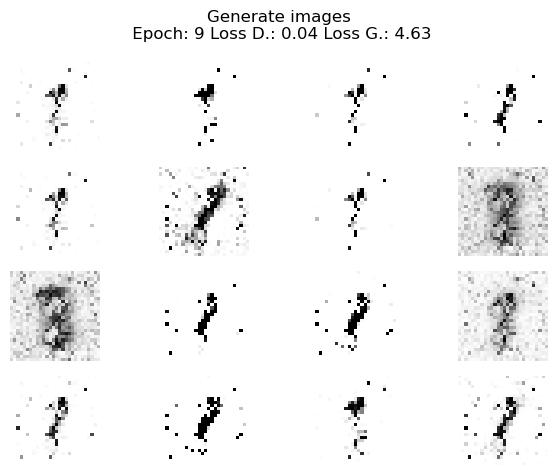

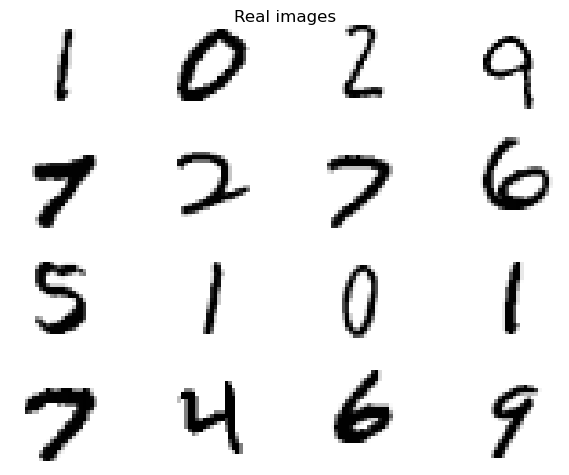

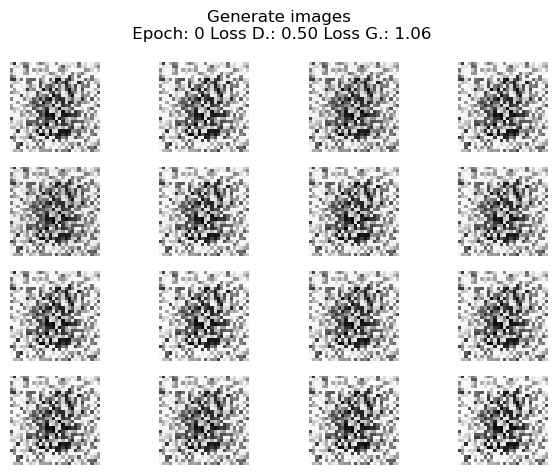

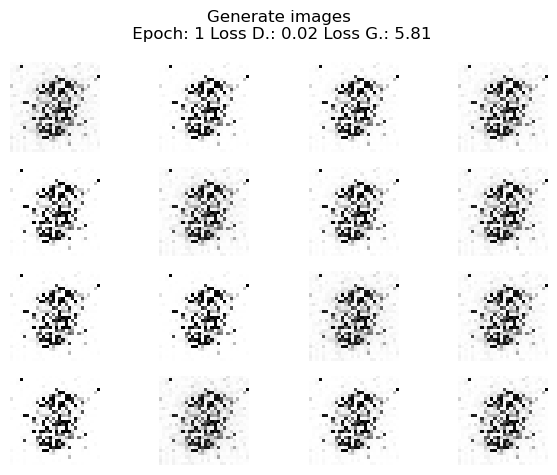

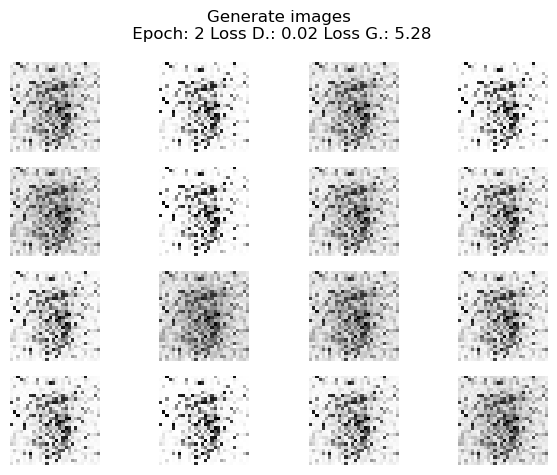

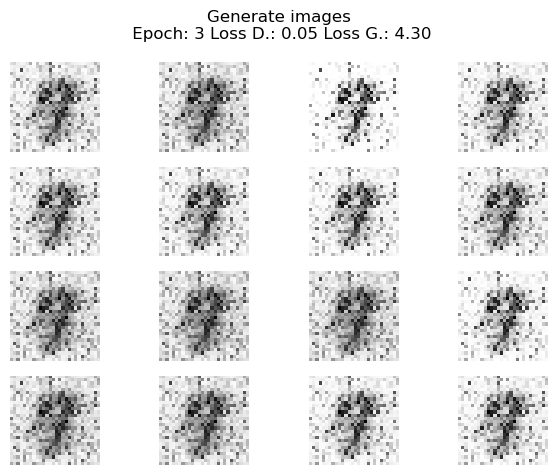

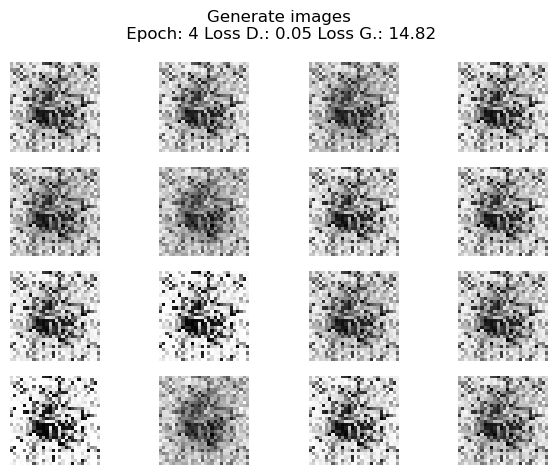

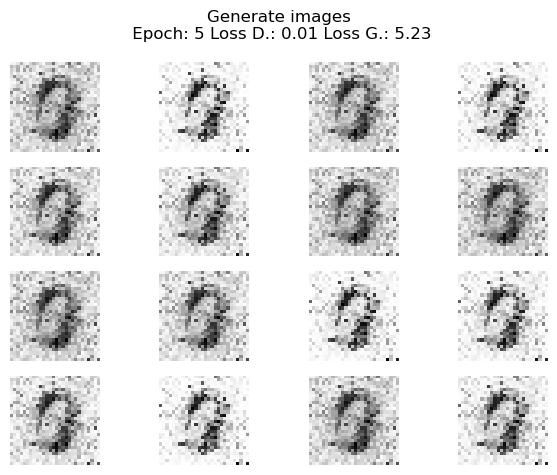

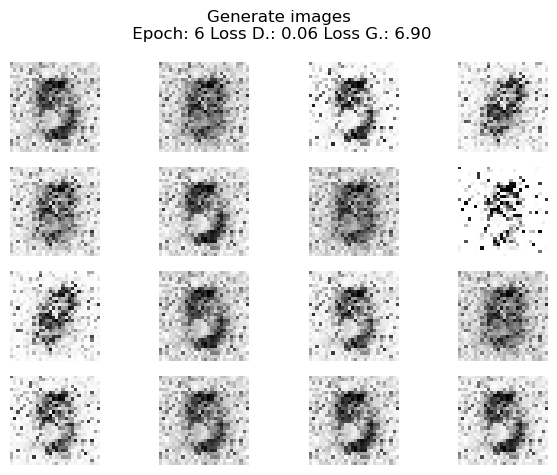

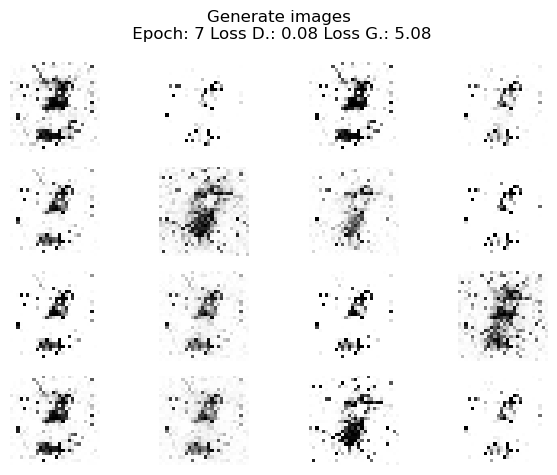

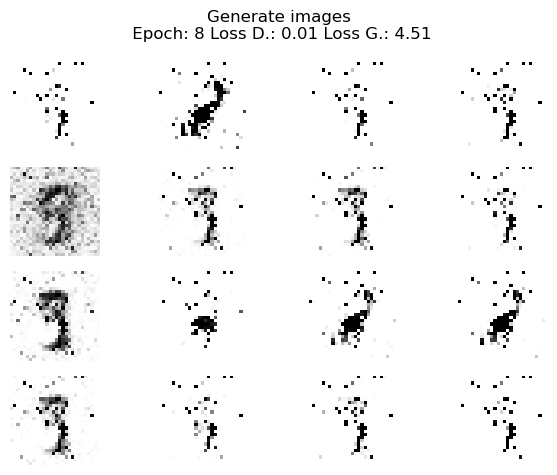

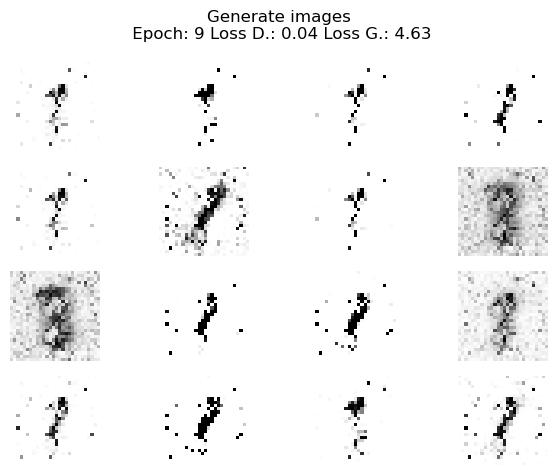

In [30]:
train_gan(batch_size=64, num_epochs=10)

## 6. Cosmetic Bug
#### After correcting the structural error, the GAN training worked correctly and all epochs were generated successfully. However, a visual issue still appeared in the VS Code/Jupyter notebook output.

#### Some figures were displayed twice and out of order. Initially, the last generated epoch appeared duplicated at both the beginning and the end of the notebook output. After correcting that behavior, the duplicated figure problem shifted to the initial "Real images" figure, which also started appearing twice.

#### The issue was caused by matplotlib figures remaining open after being displayed with:

In [ ]:
display(fig)

#### As a result, VS Code/Jupyter automatically rendered previously opened figures again at the end of the notebook execution.
#### The problem was solved by explicitly closing each figure after displaying it:

In [ ]:
display(fig)
plt.close(fig)

#### This fix was applied both to the generated epoch figures and to the initial "Real images" figure. After the correction, all images were displayed only once and in the correct order during training.

## 7. Cosmetic fix

In [34]:
# You can copy this code to your personal pipeline project or execute it here.
def train_gan(batch_size: int = 32, num_epochs: int = 100, device: str = "cuda:0" if torch.cuda.is_available() else "cpu"):
    
    # Add/adjust code.

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])                   # Normalize MNIST images between -1 and 1

    try:                                                                                                            # Try downloading MNIST dataset
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)
    except:                                                                                                         # If download fails, retry using backup URLs
        print("Failed to download MNIST, retrying with different URL")
        # see: https://github.com/pytorch/vision/blob/master/torchvision/datasets/mnist.py
        torchvision.datasets.MNIST.resources = [
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
             'f68b3c2dcbeaaa9fbdd348bbdeb94873'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
             'd53e105ee54ea40749a09fcbcd1e9432'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
             '9fb629c4189551a2d022fa330f9573f3'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz',
             'ec29112dd5afa0611ce80d1b7f02629c')
        ]
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)            # Retry dataset download

    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)                      # Create batches of data

    # example data
    real_samples, mnist_labels = next(iter(train_loader))                                                           # Display example real images

    fig = plt.figure()
    for i in range(16):
        sub = fig.add_subplot(4, 4, 1 + i)
        sub.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
        sub.axis('off')

    fig.tight_layout()
    fig.suptitle("Real images")
    display(fig)
    plt.close(fig)                                                                                                  # Cosmetic fix: close real images figure after display

    time.sleep(5)

    # Set up training
    discriminator = Discriminator().to(device)                                                                      # Initialize GAN networks
    generator = Generator().to(device)
    lr = 0.0001                                                                                                     # Learning rate
    loss_function = nn.BCELoss()                                                                                    # Binary Cross Entropy loss
    optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)                                   # Optimizers
    optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

    # train
    for epoch in range(num_epochs):                                                                                 # Training loop
        for n, (real_samples, mnist_labels) in enumerate(train_loader):

            # Data for training the discriminator
            real_samples = real_samples.to(device=device)                                                           # Move real images to device    
            real_batch_size = real_samples.size(0)                                                                  # Added variable to obtain the real batch size dynamically
            real_samples_labels = torch.ones((real_batch_size, 1)).to(device=device)                                # Modified to use the real batch size instead of the fixed batch_size
            latent_space_samples = torch.randn((real_batch_size, 100)).to(device=device)                            # Modified latent vectors size to match the real batch size
            generated_samples = generator(latent_space_samples)                                                     # Generate fake images
            generated_samples_labels = torch.zeros((real_batch_size, 1)).to(device=device)                          # Modified fake labels size to match the real batch size
            all_samples = torch.cat((real_samples, generated_samples))                                              # Combine real and fake samples
            all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))                         # Combine labels

            # Training the discriminator
            discriminator.zero_grad()
            output_discriminator = discriminator(all_samples)
            loss_discriminator = loss_function(output_discriminator, all_samples_labels)
            loss_discriminator.backward()
            optimizer_discriminator.step()

            # Data for training the generator
            latent_space_samples = torch.randn((real_batch_size, 100)).to(device=device)                            # Modified generator latent vectors to use the real batch size

            # Training the generator
            generator.zero_grad()
            generated_samples = generator(latent_space_samples)
            output_discriminator_generated = discriminator(generated_samples)
            loss_generator = loss_function(output_discriminator_generated, real_samples_labels)                     # Generator tries to fool discriminator
            loss_generator.backward()
            optimizer_generator.step()

            # Show loss and samples generated
            if n == batch_size - 1:                                                                                 # Show generated images during training
                name = f"Generate images\n Epoch: {epoch} Loss D.: {loss_discriminator:.2f} Loss G.: {loss_generator:.2f}"
                generated_samples = generated_samples.detach().cpu().numpy()
                fig = plt.figure()
                for i in range(16):
                    sub = fig.add_subplot(4, 4, 1 + i)
                    sub.imshow(generated_samples[i].reshape(28, 28), cmap="gray_r")
                    sub.axis('off')
                fig.suptitle(name)
                fig.tight_layout()
                display(fig)
                plt.close(fig)                                                                              # Cosmetic fix: prevent duplicated rendering of the last epoch figure



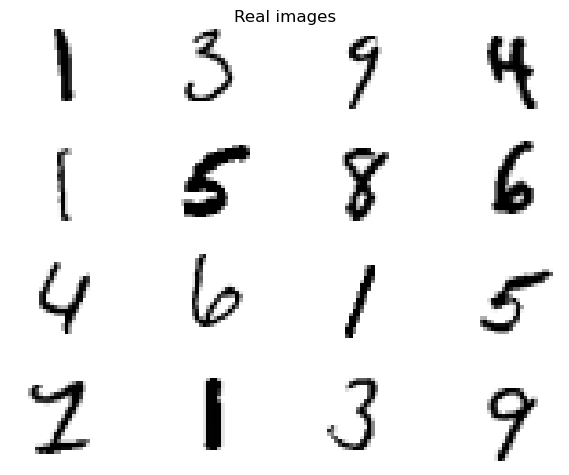

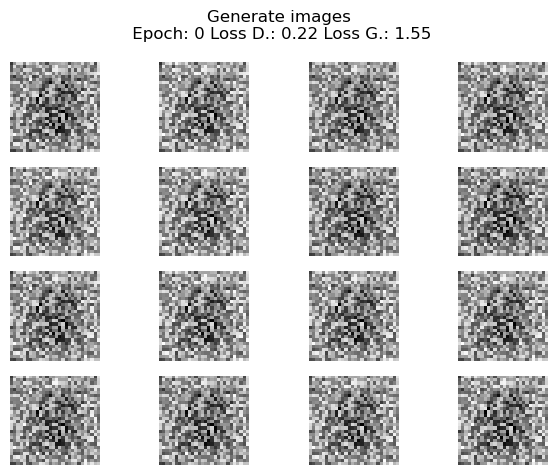

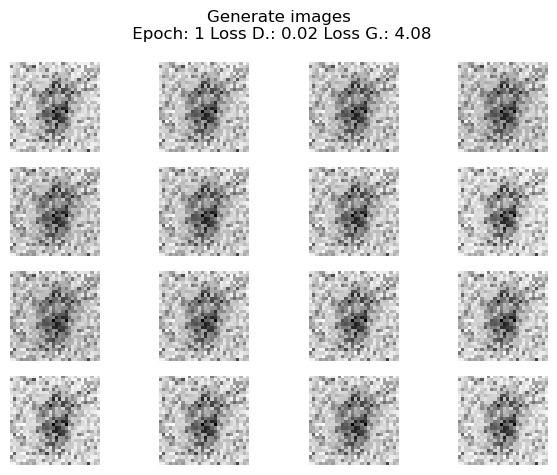

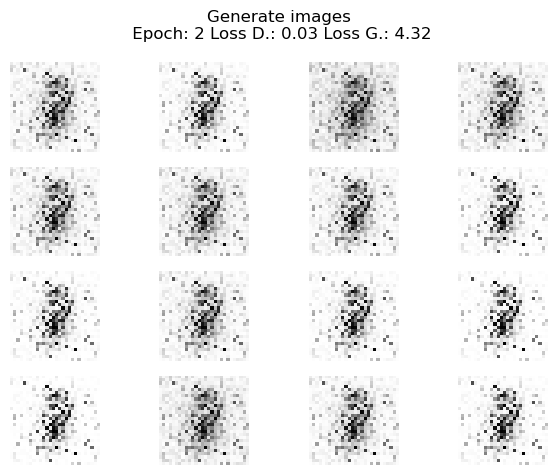

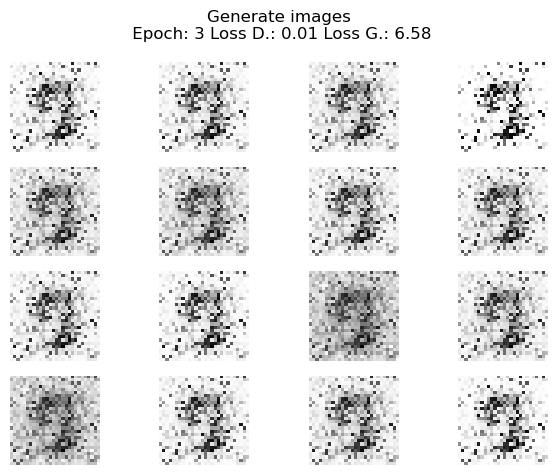

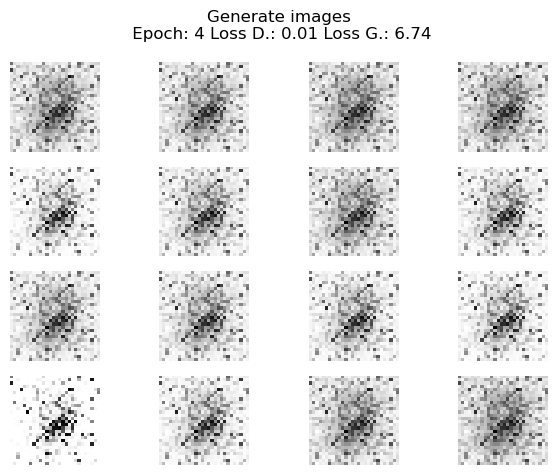

In [35]:
train_gan(batch_size=100, num_epochs=5)